In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [21]:
np.random.seed(42) #Valor adoptado por la comunidad
n = 500

In [22]:
#Datos sintéticos
MedInc = np.random.lognormal(mean=2.5, sigma=0.35, size=n)
HouseAge = np.random.randint(low=1, high=52, size=n)
Longitude = -124 + np.random.rand(n) * 10
Latitude = 32 + np.random.rand(n) * 8
AvRooms = 5 + 0.15 * MedInc + 0.03 + np.random.rand(n)

#target
target = (
    0.45 * MedInc
    - 0.2 * HouseAge
    - 0.3 * (Latitude-36)
    - 0.1 * (Longitude+119)
    + np.random.randn(n) * 0.5
    + 0.2 * AvRooms
)

#Generamos el data frame con las varibles creadas en la parte de arriba
df = pd.DataFrame(
    {
        "MedInc": MedInc,
        "HouseAge": HouseAge,
        "Longitude": Longitude,
        "Latitude": Latitude,
        "AvRooms": AvRooms,
        "target": target,
    }
)

numeric_cols = df.columns.tolist()

In [23]:
cov_mar = df[numeric_cols].cov()
corr_mat = df[numeric_cols].corr()

print("Covariance matrix:\n", cov_mar.round(3))
print("\nCorrelation matrix:\n", corr_mat.round(3))

Covariance matrix:
            MedInc  HouseAge  Longitude  Latitude  AvRooms  target
MedInc     22.967    -3.196      0.114     0.694    3.345  11.501
HouseAge   -3.196   222.304     -2.162    -0.080   -0.613 -46.030
Longitude   0.114    -2.162      8.644     0.390    0.028  -0.501
Latitude    0.694    -0.080      0.390     5.031    0.114  -1.249
AvRooms     3.345    -0.613      0.028     0.114    0.573   1.722
target     11.501   -46.030     -0.501    -1.249    1.722  15.509

Correlation matrix:
            MedInc  HouseAge  Longitude  Latitude  AvRooms  target
MedInc      1.000    -0.045      0.008     0.065    0.922   0.609
HouseAge   -0.045     1.000     -0.049    -0.002   -0.054  -0.784
Longitude   0.008    -0.049      1.000     0.059    0.013  -0.043
Latitude    0.065    -0.002      0.059     1.000    0.067  -0.141
AvRooms     0.922    -0.054      0.013     0.067    1.000   0.578
target      0.609    -0.784     -0.043    -0.141    0.578   1.000


In [24]:
# Hat-Matrix

#Separamos Y
y = df["target"].values.reshape(-1,1)
x = df[["MedInc", "AvRooms", "HouseAge", "Latitude", "Longitude"]].values

In [25]:
XtX = x.T @ x #Con la @ multiplicamos las matrices
XtX_inv = np.linalg.inv(XtX)
beta = XtX_inv @ x.T @ y
y_hat = x @ beta

print("Beta:\n", beta)
print("\ny hat (vector):\n", y_hat)

Beta:
 [[ 0.44905816]
 [ 0.22958183]
 [-0.20105544]
 [-0.31481756]
 [-0.09408132]]

y hat (vector):
 [[ 1.77767473e+00]
 [ 1.08246980e+00]
 [-4.02079102e-01]
 [ 1.13109123e+01]
 [-1.19891474e+00]
 [-4.29048423e-01]
 [ 5.90094912e+00]
 [ 4.98661025e+00]
 [ 3.67194639e+00]
 [ 5.70680654e+00]
 [-3.50671053e+00]
 [ 4.71884047e+00]
 [ 1.70360811e+00]
 [ 2.45628801e+00]
 [-1.80787519e+00]
 [ 3.56238464e-01]
 [ 2.22865743e-01]
 [ 5.32456286e+00]
 [ 4.65568691e+00]
 [-5.09593287e+00]
 [ 5.07837432e+00]
 [-1.42667797e+00]
 [-2.46664070e-02]
 [-2.89192480e+00]
 [ 2.77799835e+00]
 [ 1.15338500e+00]
 [ 4.96907001e+00]
 [ 6.79292420e+00]
 [ 6.84511385e-01]
 [ 4.96944917e-01]
 [ 3.30132929e+00]
 [ 1.03277294e+01]
 [ 3.44140809e+00]
 [ 2.46740007e+00]
 [-1.83208531e+00]
 [-9.45950634e-02]
 [ 4.39375217e-01]
 [-6.44965716e+00]
 [ 5.01963088e+00]
 [ 3.97965985e+00]
 [ 6.35531052e+00]
 [ 5.59629177e+00]
 [ 6.53291590e-01]
 [-3.91434718e+00]
 [-4.60411061e+00]
 [-3.55472584e+00]
 [ 5.18835514e+00]
 [ 7.0

In [26]:
resid = y - y_hat

#Hat matrix
H = x @ XtX_inv @ x.T
leverage = np.diag(H)
print(leverage)

[0.0067777  0.00791965 0.00848184 0.01721528 0.00440527 0.00524618
 0.01259133 0.00978354 0.01533104 0.01202193 0.00705596 0.01076172
 0.00231952 0.00898133 0.00832251 0.00455533 0.00432269 0.00838801
 0.01196078 0.01361513 0.00732137 0.01286356 0.01141785 0.00569132
 0.01645886 0.00377398 0.01420365 0.00848121 0.00987534 0.00275364
 0.00840267 0.02416694 0.00880387 0.01549486 0.01409318 0.01317521
 0.00470376 0.01161923 0.01379768 0.0033949  0.00504532 0.0081543
 0.00805018 0.00793986 0.00830262 0.00970537 0.00709739 0.01712113
 0.00722534 0.01873895 0.00310466 0.00460846 0.00490986 0.0046646
 0.01330399 0.01080101 0.01134205 0.00894692 0.00301744 0.01105025
 0.00628748 0.00516942 0.00873375 0.00728679 0.00489123 0.01563332
 0.01712086 0.00576996 0.01268705 0.01077655 0.0069642  0.01323923
 0.00395163 0.01208258 0.01836526 0.01415232 0.0040989  0.00692973
 0.00998786 0.00685666 0.00995547 0.01270541 0.02037594 0.00445013
 0.007137   0.00558626 0.0100276  0.00938676 0.00990479 0.005508

In [27]:
print("H:", H.shape)
print("\ny:", y.shape)
print("\nx:", x.shape)
print("\nbeta:\n", beta)

H: (500, 500)

y: (500, 1)

x: (500, 5)

beta:
 [[ 0.44905816]
 [ 0.22958183]
 [-0.20105544]
 [-0.31481756]
 [-0.09408132]]


In [28]:
summary = pd.DataFrame(
    {
        "index": np.arange(n),
        "leverage": leverage,
        "y": y.flatten(),
        "y_hat": y_hat.flatten(),
        "resid": resid.flatten(),
    }
)

In [29]:
print("Top Ten Leverage Points")

print(summary.sort_values(by="leverage", ascending=False).head(10).round(3))

Top Ten Leverage Points
     index  leverage       y   y_hat  resid
209    209     0.115  22.961  23.980 -1.019
478    478     0.052  15.367  15.232  0.135
179    179     0.034  10.314  10.327 -0.012
234    234     0.028   3.275   3.649 -0.374
220    220     0.028  10.394   9.965  0.429
113    113     0.028   7.998   7.535  0.463
323    323     0.024   7.574   7.878 -0.304
31      31     0.024  11.138  10.328  0.811
284    284     0.024  13.164  11.502  1.662
252    252     0.024   4.821   4.811  0.010


In [30]:
n, p = x.shape
print("n", n)
print("p", p)

avg_lev = p/n
treshold = 2*avg_lev

print("avg_lev:", avg_lev)
print("treshold:", treshold)

n 500
p 5
avg_lev: 0.01
treshold: 0.02


<function matplotlib.pyplot.show(close=None, block=None)>

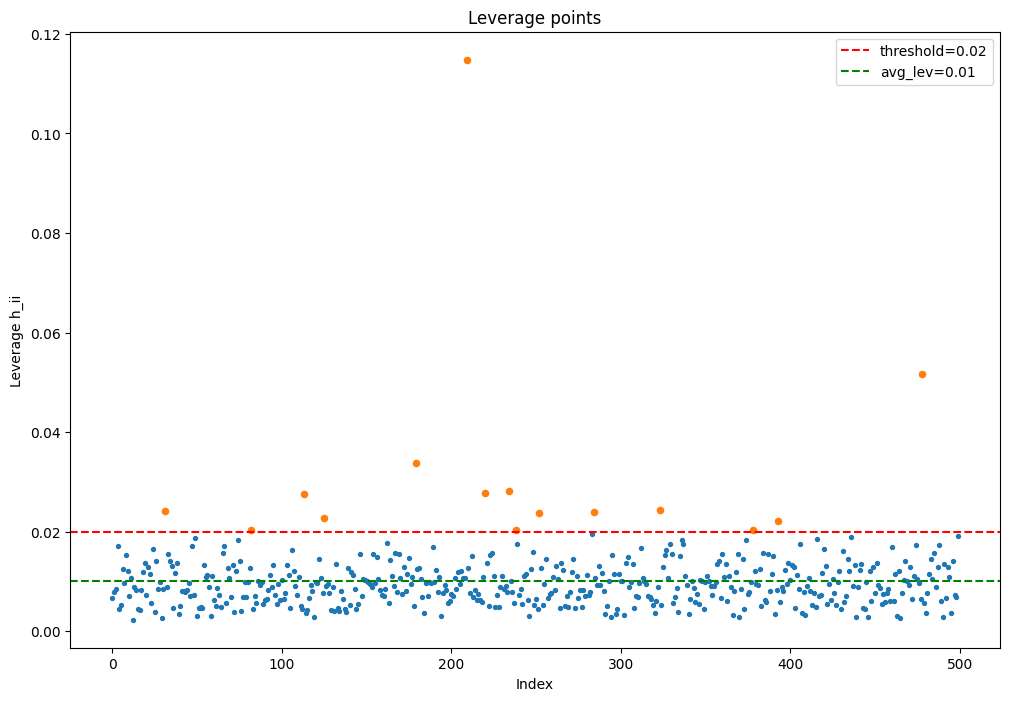

In [31]:
#Plotting leverage points
plt.figure(figsize=(12, 8))
plt.scatter(summary["index"], summary["leverage"], s=8)
plt.axhline(treshold, color="r", linestyle="--", label=f"threshold={treshold:.2f}")
plt.axhline(avg_lev, color='g', linestyle="--", label=f"avg_lev={avg_lev:.2f}")
hi_idx = summary.index[summary["leverage"]>treshold].tolist()
if len(hi_idx) > 0:
    plt.scatter(hi_idx, summary.loc[hi_idx, "leverage"], s=20)
plt.title("Leverage points")
plt.xlabel("Index")
plt.ylabel("Leverage h_ii")
plt.legend()
plt.show

# 6 de octubre de 2025

In [32]:
import statsmodels.api as sm

In [33]:
# Generate synthetic data
np.random.seed()

#Normal house
house_size = np.random.normal(2000, 400, 100)
house_price = 100 + 0.5 * house_size + np.random.normal(0, 20000, 100)

#Mansions
house_size = np.append(house_size, [5000, 6000, 7000]) #Con el append agregamos la información nueva junto con la que ya teníamos
house_price = np.append(house_price, [450_000, 550_000, 800_000])

#Fit a linear model
X = sm.add_constant(house_size)
model = sm.OLS(house_price, X).fit() #OLS - Ordinary Linear Square

In [34]:
#Printing model parameter
print("Model with mansions:")
print(f"Intercept: {model.params[0]:.2f}")
print(f"Slope: {model.params[1]:.2f}")

Model with mansions:
Intercept: -215335.51
Slope: 112.51


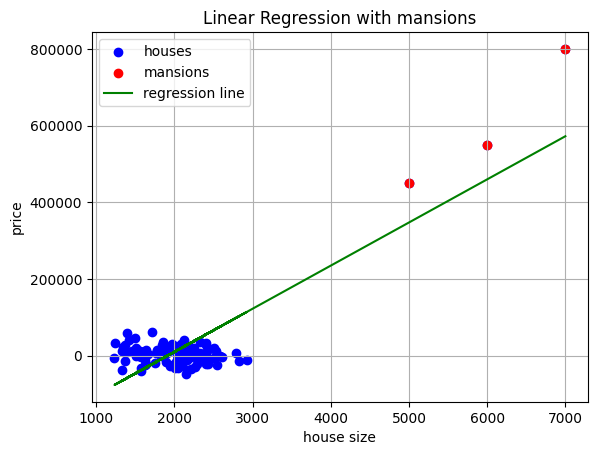

In [35]:
#plot the data
plt.figure()
plt.scatter(house_size, house_price, label='houses', color='b')
plt.scatter(house_size[-3:], house_price[-3:], label='mansions', color='r') #Tomar ultimos 3 puntos agregados
plt.plot(house_size, model.params[0] + model.params[1] * house_size, color='g', label='regression line')
plt.legend()
plt.title("Linear Regression with mansions")
plt.xlabel("house size")
plt.ylabel("price")
plt.grid(True)
plt.show()

Con esta gráfica podemos ver que las 3 mansiones jalan de forma exponencial la regresión lineal a comparación del conjunto de datos que tenemos de las casas. Sin embargo, no por eso tenemos que descartar estos puntos porque en caso de que los datos de las casas tengan una dirección hacía las mansiones significa que la regresión lineal es correcta y las mansiones no son datos tan alejados como parecia al principio

In [36]:
#Get the leverage points
influence = model.get_influence()
leverage = influence.hat_matrix_diag
residuals = model.resid

#Threshold
n = len(house_size)
p = X.shape[1]
avg_lev = p/n
threshold = 2 * avg_lev
print(threshold)

0.038834951456310676


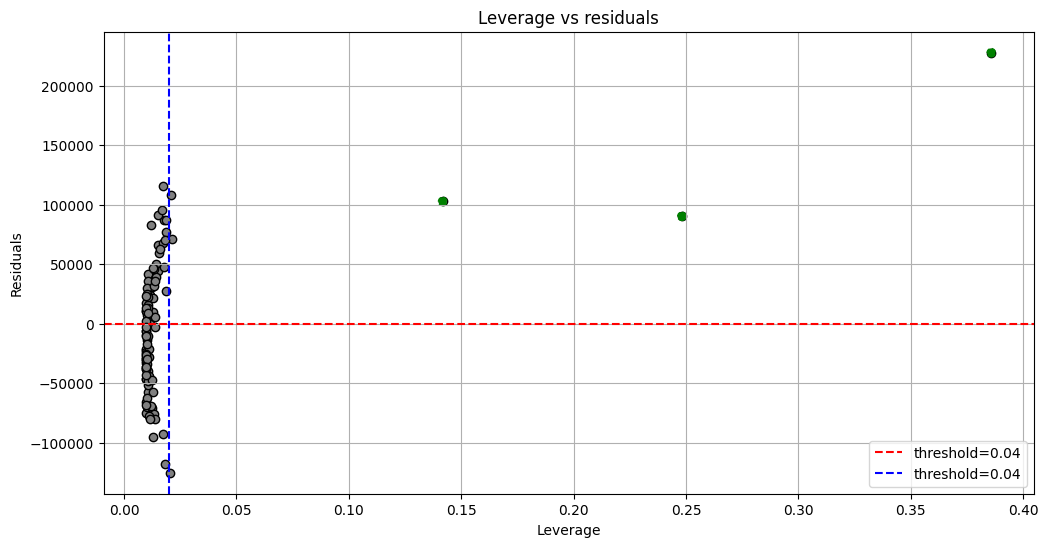

In [37]:
plt.figure(figsize=(12, 6))
plt.scatter(leverage, residuals, edgecolors='black', facecolors='grey')
plt.axhline(0, color='r', linestyle="--", label=f"threshold={threshold:.2f}")
plt.axvline(treshold, color='b', linestyle="--", label=f"threshold={threshold:.2f}")
plt.legend()
plt.title("Leverage vs residuals")
plt.xlabel("Leverage")
plt.ylabel("Residuals")
plt.grid(True)

high_leverage_points = np.where(leverage>threshold)
plt.scatter(leverage[high_leverage_points], residuals[high_leverage_points], color='green', linestyle="--", label="high leverage points")

plt.show()

In [38]:
print(f"High leverage points (index): {high_leverage_points}")
print(f"Leverage values: {leverage[high_leverage_points]}")

High leverage points (index): (array([100, 101, 102]),)
Leverage values: [0.14174283 0.24814737 0.38577033]
